In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bitcoin = pd.read_csv("BTC-EUR.csv")
bitcoin.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
1,2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2,2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
3,2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
4,2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


<Axes: >

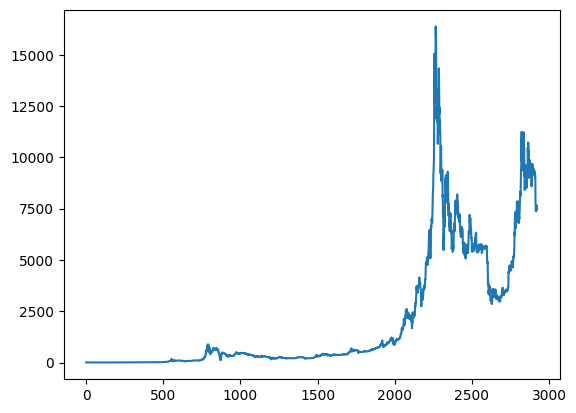

In [3]:
bitcoin['Close'].plot()


In [4]:
# donnons une index de tyoe DateTime a notre data
bitcoin = pd.read_csv("BTC-EUR.csv", index_col="Date", parse_dates=True) 

bitcoin.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2011-10-04,3.700,3.821,3.746,3.750,3.750,1357
2011-10-05,3.750,3.820,3.650,3.676,3.676,3349
2011-10-06,3.676,3.743,3.450,3.550,3.550,6642
2011-10-07,3.550,3.590,2.900,3.293,3.293,7135
2011-10-08,3.293,3.283,2.872,2.890,2.890,2007


<Axes: xlabel='Date'>

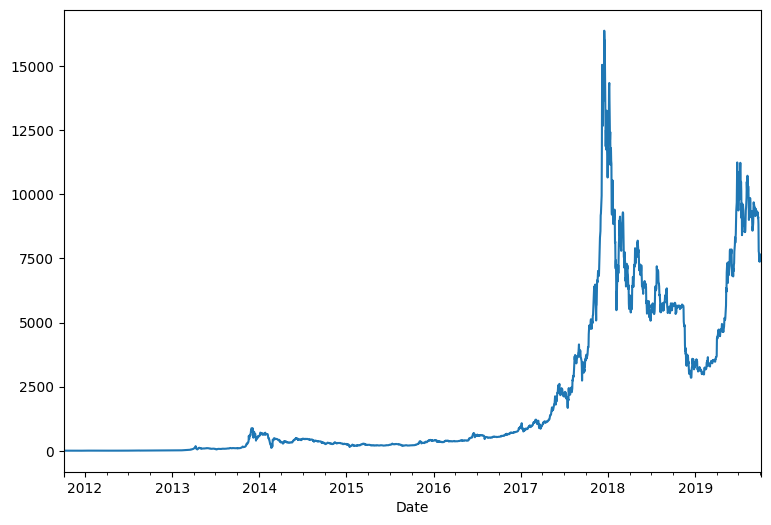

In [5]:
bitcoin["Close"].plot(figsize=(9,6))

Analyse de TimeSirie

<Axes: xlabel='Date'>

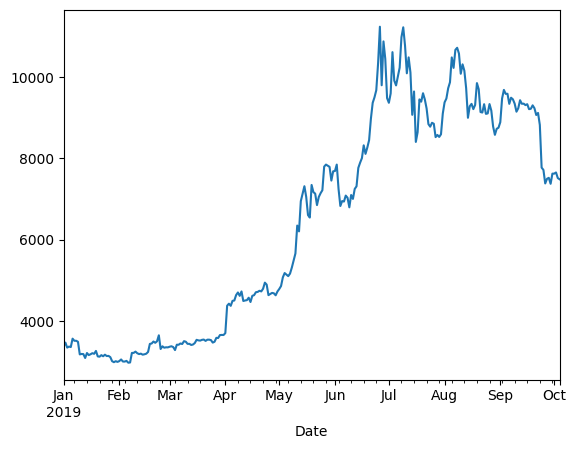

In [6]:
# observeons l'evolution du bitcoin en 2014
bitcoin["2019-01":"2019-12"]['Close'].plot()

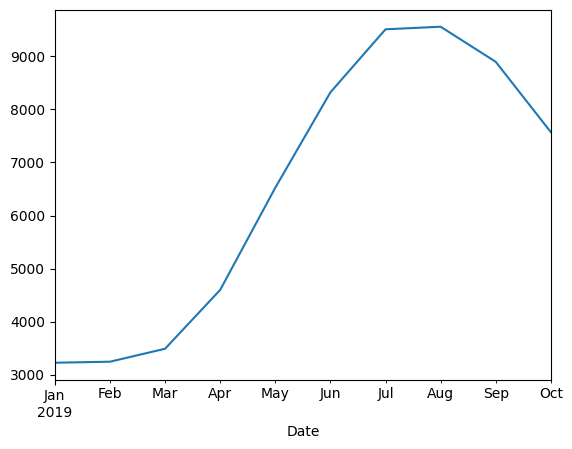

In [7]:
# resample () permet de de regrouper des timeserie en fonction de certaines frequences
bitcoin.loc["2019","Close"].resample("ME").mean().plot()
plt.show()


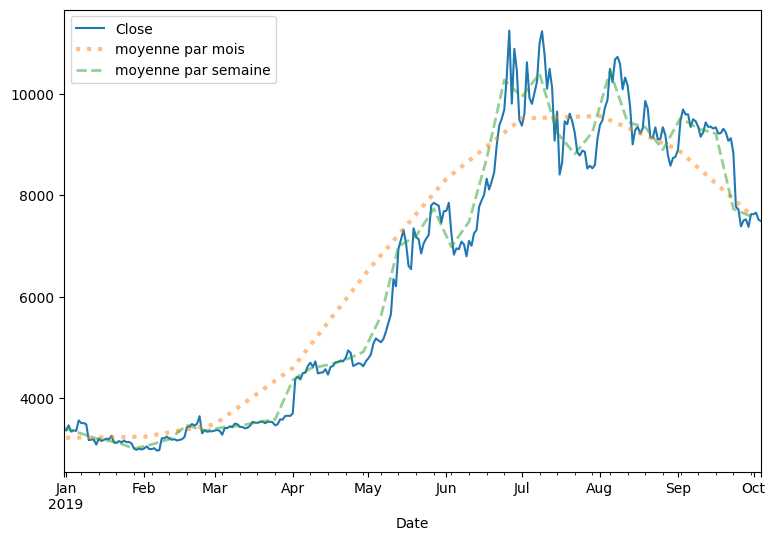

In [8]:
plt.figure(figsize=(9,6))
bitcoin.loc["2019","Close"].plot()
bitcoin.loc["2019","Close"].resample("ME").mean().plot(label="moyenne par mois", lw=3, ls=":", alpha=0.5)
bitcoin.loc["2019","Close"].resample("W").mean().plot(label="moyenne par semaine", lw=2, ls="--", alpha=0.5)
plt.legend()
plt.show()

# dans la pratique on represente ainsi representent les graphes

In [58]:
bitcoin["Close"].resample("W").agg(['mean',"std","min","max"]).head()


,mean,std,min,max
Date,,,,
2011-10-09,3.356167,0.363120,2.890,3.750
2011-10-16,2.908000,0.177088,2.587,3.090
2011-10-23,1.910714,0.258091,1.620,2.274
2011-10-30,2.174000,0.244941,1.872,2.574
2011-11-06,2.281000,0.087130,2.170,2.420


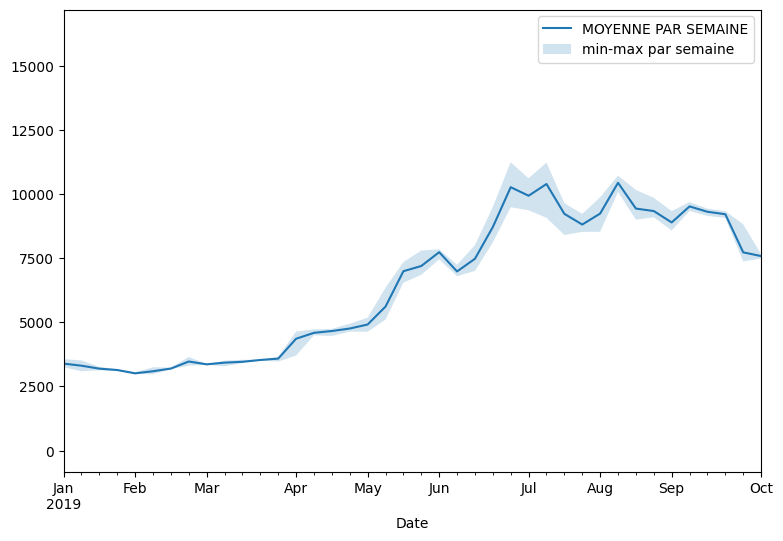

In [9]:
m = bitcoin["Close"].resample("W").agg(['mean',"std","min","max"])
plt.figure(figsize=(9,6))
m['mean']["2019"].plot(label="MOYENNE PAR SEMAINE")
plt.fill_between(m.index,m['max'], m["min"],label="min-max par semaine", alpha=0.2)
plt.legend()
plt.show()

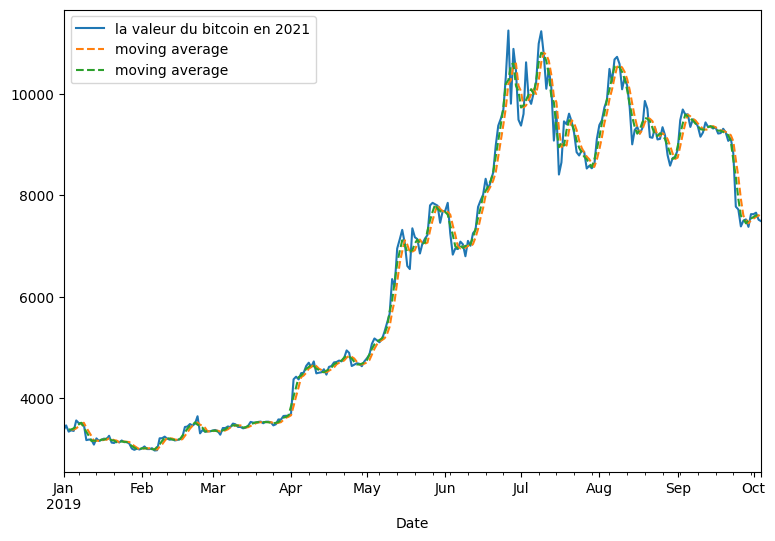

In [23]:
# rolling

plt.figure(figsize=(9,6))
bitcoin.loc['2019', "Close"].plot(label="la valeur du bitcoin en 2021")
bitcoin.loc['2019', "Close"].rolling(window=4).mean().plot(label="moving average", ls="--")
bitcoin.loc['2019', "Close"].rolling(window=4, center=True).mean().plot(label="moving average", ls="--")
plt.legend()
plt.show()

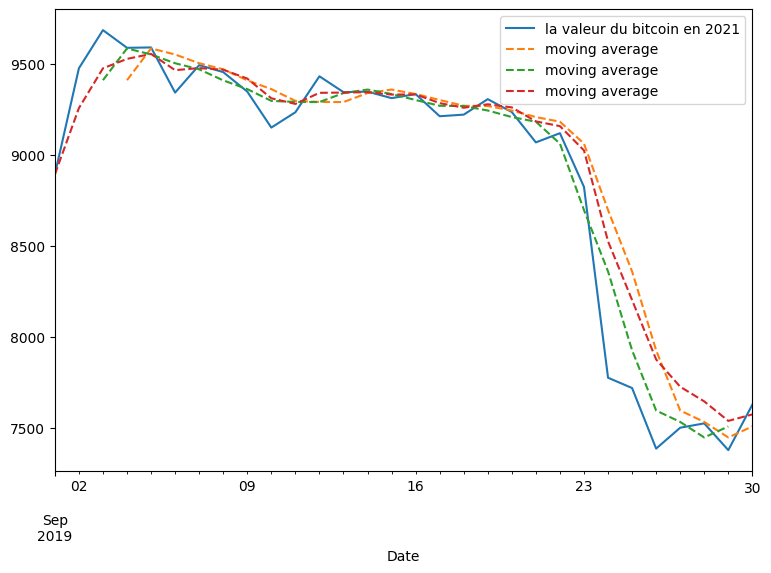

In [27]:
# rolling

plt.figure(figsize=(9,6))
bitcoin.loc['2019-9', "Close"].plot(label="la valeur du bitcoin en 2021")
bitcoin.loc['2019-9', "Close"].rolling(window=4).mean().plot(label="moving average", ls="--")
bitcoin.loc['2019-9', "Close"].rolling(window=4, center=True).mean().plot(label="moving average", ls="--")
bitcoin.loc['2019-9', "Close"].ewm(alpha=0.4).mean().plot(label="ewp weighted", ls="--")
plt.legend()
plt.show()

# le rolling ne permettant n'est pas des fois adapter pour le calcule des moyennes.
# la function ewn() est souvent la plus adapte

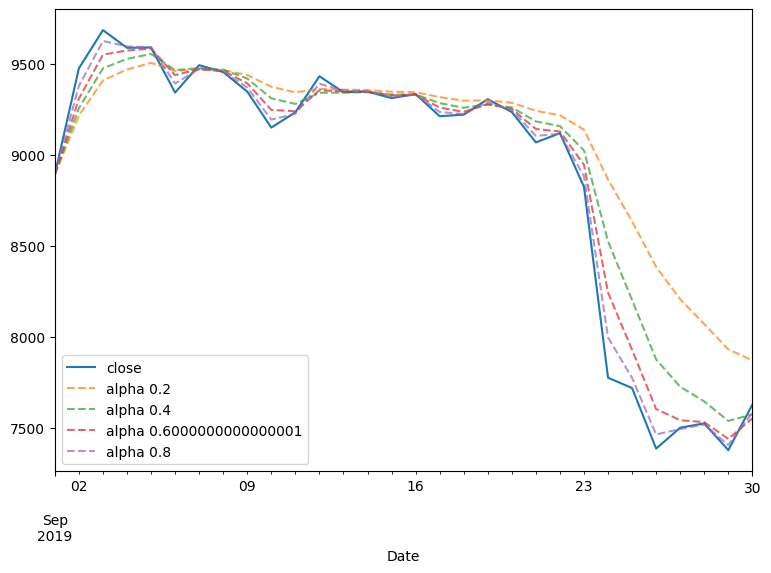

In [31]:
plt.figure(figsize=(9,6))
bitcoin.loc['2019-9', "Close"].plot(label="close")
for i in np.arange(0.2,1,0.2):
    bitcoin.loc['2019-9', "Close"].ewm(alpha=i).mean().plot(label=f"alpha {i}", ls="--", alpha=0.7)
plt.legend()
plt.show()

# pour pour i = 0.8 est la moyenne estplus proche de notre bitcoin

# Assamblage de dataset


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-08-07,0.593000,20.000000,0.593000,2.560000,2.560000,15200
2015-08-08,2.560000,2.598000,0.561600,0.650000,0.650000,32816
2015-08-09,0.650000,0.800000,0.523500,0.700000,0.700000,4041
2015-08-10,0.700000,0.750000,0.585000,0.680000,0.680000,5645
2015-08-11,0.680000,1.008000,0.591500,0.950000,0.950000,21607
...,...,...,...,...,...,...
2019-09-30,155.160004,166.649994,151.229996,165.910004,165.910004,15659055
2019-10-01,165.910004,170.710007,159.330002,161.410004,161.410004,11427525
2019-10-02,161.410004,165.740005,159.699997,165.240005,165.240005,5760811


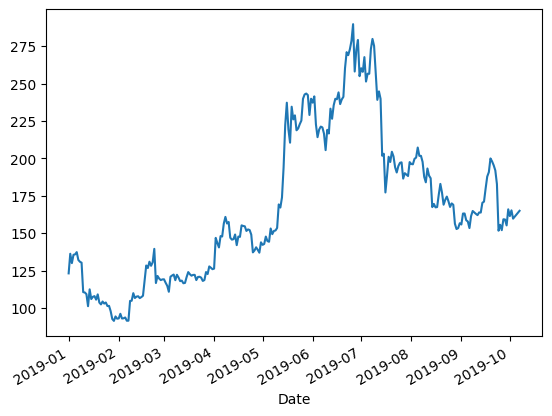

In [58]:
etherium = pd.read_csv("ETH-EUR.csv", index_col='Date',  parse_dates=True)
etherium.loc["2019","Close"].plot()
etherium

In [59]:
# ASSEMBLAGE

btc_eth = pd.merge(bitcoin, etherium,on='Date', how='inner', suffixes=("_btc", "_eth") )
btc_eth
# on = Date , on designe le parametre en commun
# how = 'inner' on choisi le mehtode d'assamblade
# suffixes=("_btc", "_etc"), on ajoute respectivement un suffixes aux colonnes du tableau de bitcoin et etherium

,Open_btc,High_btc,Low_btc,Close_btc,Adj Close_btc,Volume_btc,Open_eth,High_eth,Low_eth,Close_eth,Adj Close_eth,Volume_eth
Date,,,,,,,,,,,,
2015-08-07,255.710007,258.880005,253.639999,256.250000,256.250000,1446808,0.593000,20.000000,0.593000,2.560000,2.560000,15200
2015-08-08,256.250000,257.029999,239.279999,240.199997,240.199997,1426996,2.560000,2.598000,0.561600,0.650000,0.650000,32816
2015-08-09,240.199997,246.110001,239.039993,243.910004,243.910004,797790,0.650000,0.800000,0.523500,0.700000,0.700000,4041
2015-08-10,243.910004,248.039993,240.779999,241.679993,241.679993,1135445,0.700000,0.750000,0.585000,0.680000,0.680000,5645
2015-08-11,241.679993,247.190002,240.399994,245.759995,245.759995,1472221,0.680000,1.008000,0.591500,0.950000,0.950000,21607
...,...,...,...,...,...,...,...,...,...,...,...,...
2019-09-29,7523.009766,7541.020020,7247.169922,7375.950195,7375.950195,39755968,159.130005,159.779999,150.610001,155.160004,155.160004,7857348
2019-09-30,7375.950195,7667.890137,7075.589844,7626.029785,7626.029785,101457908,155.160004,166.649994,151.229996,165.910004,165.910004,15659055
2019-10-01,7626.029785,7818.279785,7535.799805,7625.560059,7625.560059,75644316,165.910004,170.710007,159.330002,161.410004,161.410004,11427525


array([<Axes: xlabel='Date'>, <Axes: xlabel='Date'>], dtype=object)

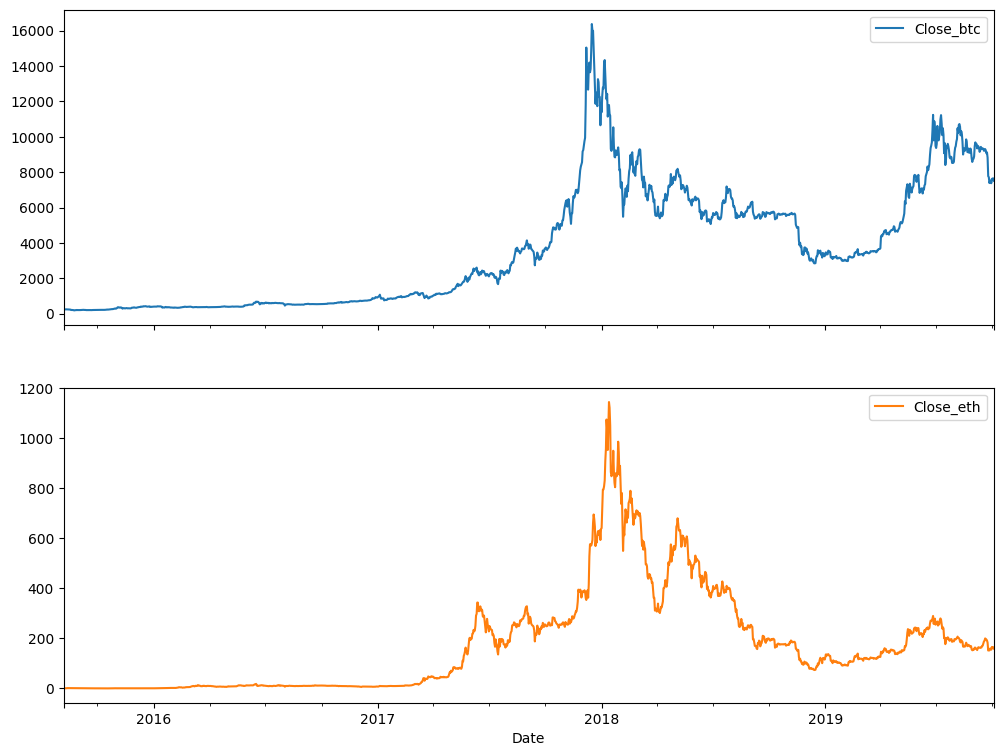

In [60]:
btc_eth[['Close_btc','Close_eth']].plot(subplots=True, figsize=(12,9))
# les deux donnes n'ayants pas la meme diemnsion on tuilise subplots pour avoir deux tableaucx
# afin de bien les visualiser.

<Axes: >

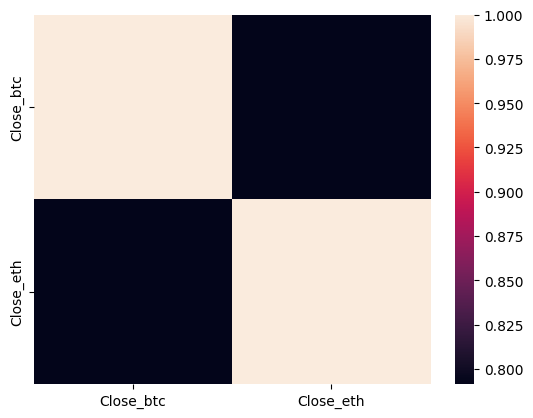

In [68]:
# calculons la correlationdes deux corbes.

correlation = btc_eth[['Close_btc','Close_eth']].corr()

import seaborn as sns

sns.heatmap(correlation)